# **Data Presprocessing:**


In [ ]:
!pip install datasets

  Using cached numpy-2.2.5-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
Using cached numpy-2.2.5-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (16.4 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.23.0
    Uninstalling numpy-1.23.0:
      Successfully uninstalled numpy-1.23.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 2.2.5 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.2.5 which is incompatible.


In [ ]:
!pip install nltk emoji


In [ ]:
import nltk
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

Read dataset from datasets package


In [ ]:
from datasets import load_dataset
dataset = load_dataset("tweet_eval", "sentiment")
dataset

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 45615
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 12284
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [ ]:
dataset['train'][0]

{'text': '"QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin"',
 'label': 2}

Converted it into a pandas dataframe for easier manipulation


Labels: 0 -> negative
1 -> neutral
2 -> positive


In [ ]:
import pandas as pd

df_train = pd.DataFrame(dataset['train'])
df_test = pd.DataFrame(dataset['test'])
df_val = pd.DataFrame(dataset['validation'])
df_train.head()

,text,label
0,"""QT @user In the original draft of the 7th boo...",2
1,"""Ben Smith / Smith (concussion) remains out of...",1
2,Sorry bout the stream last night I crashed out...,1
3,Chase Headley's RBI double in the 8th inning o...,1
4,@user Alciato: Bee will invest 150 million in ...,2


In [ ]:
print(f"The shape of train set : {df_train.shape}")
print(f"The shape of test set : {df_test.shape}")
print(f"The shape of validation set : {df_val.shape}")

The shape of train set : (45615, 2)
The shape of test set : (12284, 2)
The shape of validation set : (2000, 2)


Data cleaning and preprocessing:


In [ ]:
import re
import nltk
import emoji
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

In [ ]:
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [ ]:
!pip uninstall numpy
!pip install numpy==1.23

Found existing installation: numpy 2.2.5
Uninstalling numpy-2.2.5:
  Would remove:
    /usr/local/bin/f2py
    /usr/local/bin/numpy-config
    /usr/local/lib/python3.11/dist-packages/numpy-2.2.5.dist-info/*
    /usr/local/lib/python3.11/dist-packages/numpy.libs/libgfortran-040039e1-0352e75f.so.5.0.0
    /usr/local/lib/python3.11/dist-packages/numpy.libs/libquadmath-96973f99-934c22de.so.0.0.0
    /usr/local/lib/python3.11/dist-packages/numpy.libs/libscipy_openblas64_-6bb31eeb.so
    /usr/local/lib/python3.11/dist-packages/numpy/*
Proceed (Y/n)? Y
  Successfully uninstalled numpy-2.2.5
  Using cached numpy-1.23.0-cp311-cp311-linux_x86_64.whl
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 1.23.0 which is incompatible.
chex 0.1.89 requires numpy>=1.24.1, but you have numpy 1.23.0 which is incompat

In [ ]:
import spacy
nlp = spacy.load('en_core_web_sm')

/usr/local/lib/python3.11/dist-packages/cupyx/scipy/sparse/_base.py:10: UserWarning: A NumPy version >=1.23.5 and <2.5.0 is required for this version of SciPy (detected version 1.23.0)
  import scipy.sparse as _sparse


In [ ]:
def cleaning(text):
    lemmatizer = WordNetLemmatizer()
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)         # remove URLs
    text = re.sub(r'@\w+', '', text)                            # remove usernames
    text = re.sub(r'#\w+', '', text)                            # remove hashtags
    text = emoji.replace_emoji(text, replace='')                # remove emojis
    text = re.sub(r'\s+', ' ', text)                            #to replace multiple spaces with single one
    doc = nlp(text)
    lemmatized_tokens = [token.lemma_ for token in doc ]
    return lemmatized_tokens

In [ ]:
#testing the cleaining function
text1 = "Check out our new product! 😍😍 Visit https://example.com @brand"
text2 = "Loving the #ParisFashionWeek revolution. #ZARA is the future!"
text3 = "Great job @aly 👏👏 on your mark!"
text4 = "This is amazing! Read more at https://news.com #BreakingNews"
text5 = "🔥🔥 I am running better and last week i have looked to run 45 km. #Winning @alexandria"
for i, text in enumerate([text1, text2, text3, text4, text5], 1):
    print(f"Test Case {i}:")
    print(cleaning(text))
    print("-" * 30)

Test Case 1:
['check', 'out', 'our', 'new', 'product', '!', 'visit']
------------------------------
Test Case 2:
['love', 'the', 'revolution', '.', 'be', 'the', 'future', '!']
------------------------------
Test Case 3:
['great', 'job', 'on', 'your', 'mark', '!']
------------------------------
Test Case 4:
['this', 'be', 'amazing', '!', 'read', 'more', 'at']
------------------------------
Test Case 5:
['i', 'be', 'run', 'well', 'and', 'last', 'week', 'i', 'have', 'look', 'to', 'run', '45', 'km', '.']
------------------------------


In [ ]:
def remove_extracharacters(tokens):
   return [re.sub(r'[^A-Za-z_]', '', token) for token in tokens if re.sub(r'[^A-Za-z_]', '', token)] #remove non-word and non-whitespace characters and numbers

In [ ]:
import nltk
from nltk.corpus import stopwords

# Download stopwords from NLTK
nltk.download('stopwords')
# Get English stopwords
stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
def extra_cleaning(df):
  df['extra_cleaned'] = df['text'].apply(remove_extracharacters)
  df['extra_cleaned'] = df['extra_cleaned'].apply(remove_stopwords)
  return df

In [ ]:
import pandas as pd
data = {
    'text': [
        ['This', 'is', 'an', 'example!'],
        ['Another', '#tweet', 'with', 'punctuation...'],
        ['Clean', 'this', 'UP', 'PLEASE!!!']
    ]
}
test = pd.DataFrame(data)
print("Before cleaning:\n", test)
test = extra_cleaning(test)
print("\nAfter cleaning:\n", test)

Before cleaning:
                                       text
0                 [This, is, an, example!]
1  [Another, #tweet, with, punctuation...]
2             [Clean, this, UP, PLEASE!!!]

After cleaning:
                                       text                  extra_cleaned
0                 [This, is, an, example!]                      [example]
1  [Another, #tweet, with, punctuation...]  [Another, tweet, punctuation]
2             [Clean, this, UP, PLEASE!!!]                [Clean, PLEASE]


In [ ]:
df_train['text'] = df_train['text'].apply(cleaning)
df_test['text'] = df_test['text'].apply(cleaning)
df_val['text'] = df_val['text'].apply(cleaning)

In [ ]:
df_train = extra_cleaning(df_train)
df_test = extra_cleaning(df_test)
df_val = extra_cleaning(df_val)

In [ ]:
df_train.head()

,text,label,extra_cleaned
0,"["", qt, in, the, original, draft, of, the, 7th...",2,"[qt, original, draft, th, book, remus, lupin, ..."
1,"["", ben, smith, /, smith, (, concussion, ), re...",1,"[ben, smith, smith, concussion, remain, lineup..."
2,"[sorry, bout, the, stream, last, night, i, cra...",1,"[sorry, bout, stream, last, night, crash, toni..."
3,"[chase, headley, 's, rbi, double, in, the, 8th...",1,"[chase, headley, rbi, double, th, inning, davi..."
4,"[alciato, :, bee, will, invest, 150, million, ...",2,"[alciato, bee, invest, million, january, anoth..."


In [ ]:
df_test.head()

,text,label,extra_cleaned
0,"[what, do, these, ', 1/2, naked, pic, ', have,...",1,"[naked, pic, anything, even, like]"
1,"[oh, :, "", i, have, a, blue, penis, while, i, ...",1,"[oh, blue, penis, play, google, earth, vr]"
2,"[that, be, come, ,, but, i, think, the, victim...",1,"[come, think, victim, go, medicaid, recipient]"
3,"[i, think, i, may, be, finally, in, with, the,...",2,"[think, may, finally, crowd]"
4,"[wow, ,, first, hugo, chavez, and, now, fidel,...",0,"[wow, first, hugo, chavez, fidel, castro, dann..."


In [ ]:
df_val.head()

,text,label,extra_cleaned
0,"[dark, soul, 3, april, launch, date, confirm, ...",1,"[dark, soul, april, launch, date, confirm, new..."
1,"["", national, hot, dog, day, ,, national, tequ...",2,"[national, hot, dog, day, national, tequila, d..."
2,"[when, girl, become, bandwagon, fan, of, the, ...",0,"[girl, become, bandwagon, fan, packer, harry, ..."
3,"[i, may, or, may, not, have, search, it, up, o...",1,"[may, may, search, google]"
4,"[here, be, your, start, tuesday, morning, line...",1,"[start, tuesday, morning, line, gentle, yoga, ..."


# **EDA** -> Exploratory Data Anlaysis


In [ ]:
df = df_train.copy()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45615 entries, 0 to 45614
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   text           45615 non-null  object
 1   label          45615 non-null  int64 
 2   extra_cleaned  45615 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.0+ MB


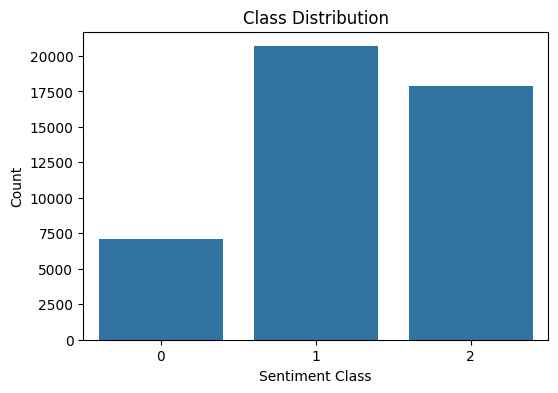

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
#plot class distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='label')
plt.title('Class Distribution')
plt.xlabel('Sentiment Class')
plt.ylabel('Count')
plt.show()

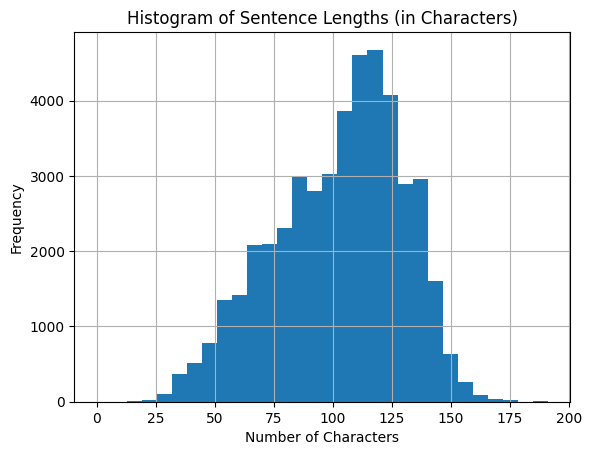

In [ ]:
df['text_length'] = df['text'].apply(lambda x: len(' '.join(x)))
#histogram of the number of characters
df['text_length'].hist(bins=30)

plt.xlabel('Number of Characters')
plt.ylabel('Frequency')
plt.title('Histogram of Sentence Lengths (in Characters)')

plt.show()

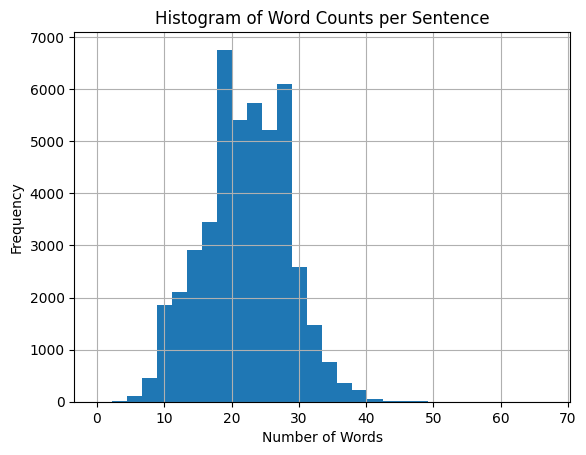

In [ ]:
df['word_count'] = df['text'].apply(len)

#histogram of word counts
df['word_count'].hist(bins=30)

plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.title('Histogram of Word Counts per Sentence')

plt.show()

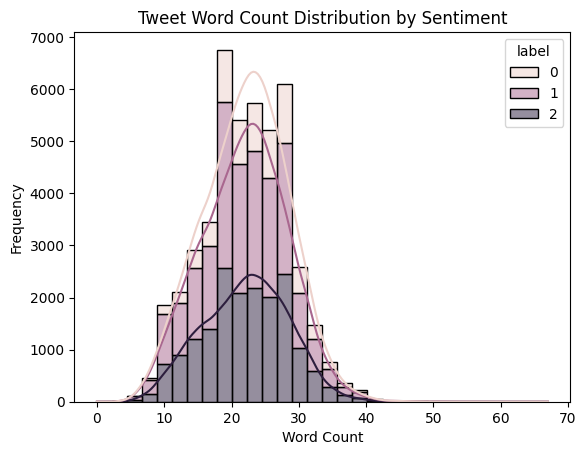

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=df, x='word_count', hue='label', bins=30, kde=True, multiple='stack')
plt.title("Tweet Word Count Distribution by Sentiment")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt

def get_top_words(token_lists, n=20):
    all_tokens = [word for tokens in token_lists for word in tokens if word.isalpha()]
    counter = Counter(all_tokens)
    return counter.most_common(n)

In [ ]:
top_words = {}

for sentiment in [0,1,2]:
    tokens = df[df['label'] == sentiment]['text']
    top_words[sentiment] = get_top_words(tokens)

Top words before removing stop words:


<ipython-input-32-d95e066771f2>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(freqs), y=list(words), palette='viridis', hue=None, legend=False)


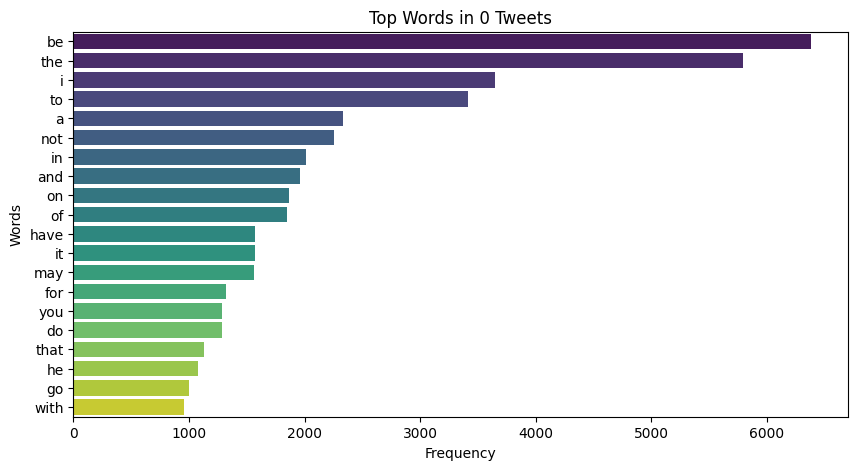

<ipython-input-32-d95e066771f2>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(freqs), y=list(words), palette='viridis', hue=None, legend=False)


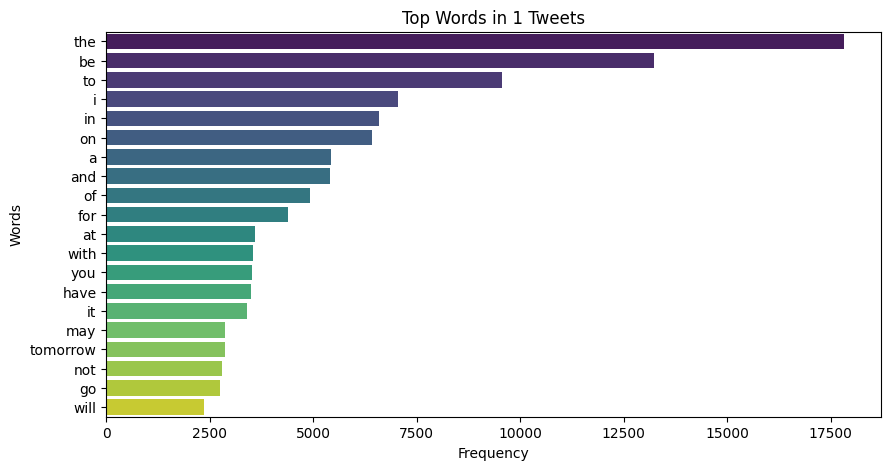

<ipython-input-32-d95e066771f2>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(freqs), y=list(words), palette='viridis', hue=None, legend=False)


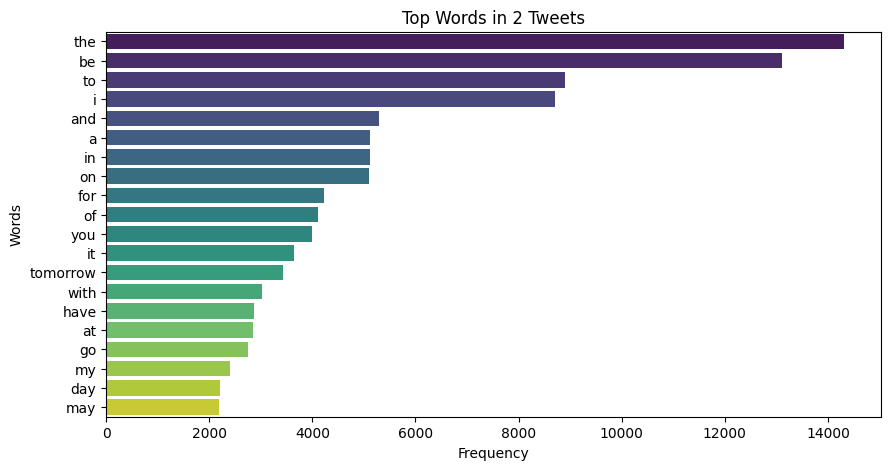

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_top_words(word_freq, sentiment):
    words, freqs = zip(*word_freq)
    plt.figure(figsize=(10, 5))
    sns.barplot(x=list(freqs), y=list(words), palette='viridis', hue=None, legend=False)
    plt.title(f"Top Words in {sentiment} Tweets")
    plt.xlabel("Frequency")
    plt.ylabel("Words")
    plt.show()

# Plot for each sentiment
for sentiment in [0,1,2]:
    plot_top_words(top_words[sentiment], sentiment)


Top words after removing stopping words:


<ipython-input-33-c7a3e7f9bc38>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(freqs), y=list(words), palette='viridis', hue=None, legend=False)


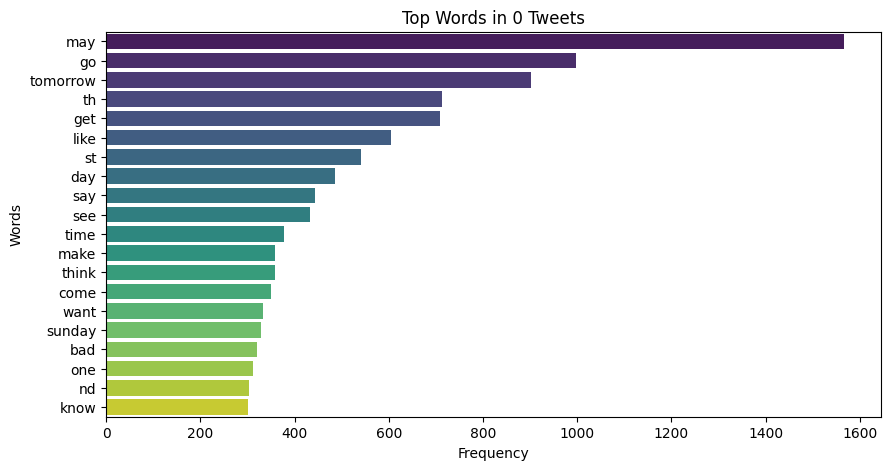

<ipython-input-33-c7a3e7f9bc38>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(freqs), y=list(words), palette='viridis', hue=None, legend=False)


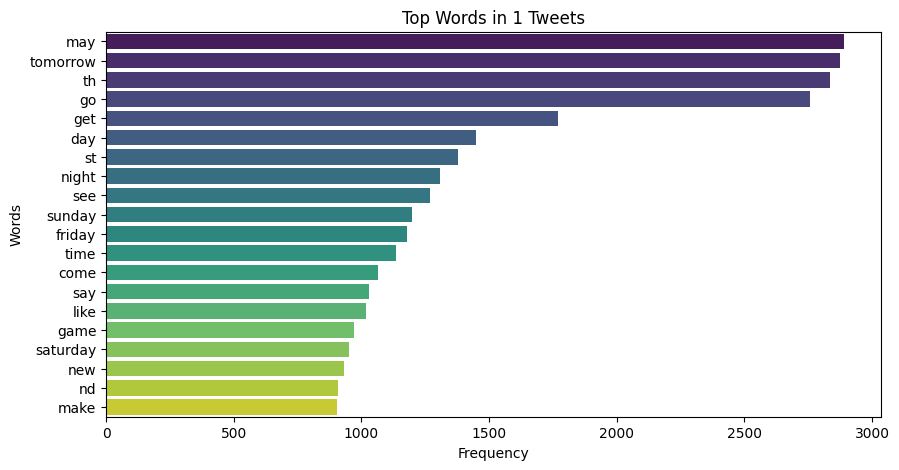

<ipython-input-33-c7a3e7f9bc38>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(freqs), y=list(words), palette='viridis', hue=None, legend=False)


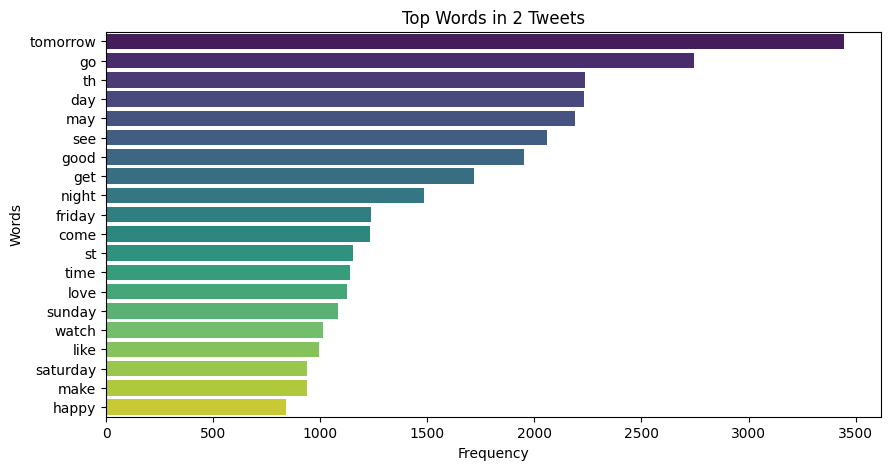

In [ ]:
top_words = {}

for sentiment in [0,1,2]:
    tokens = df[df['label'] == sentiment]['extra_cleaned']
    top_words[sentiment] = get_top_words(tokens)

def plot_top_words(word_freq, sentiment):
    words, freqs = zip(*word_freq)
    plt.figure(figsize=(10, 5))
    sns.barplot(x=list(freqs), y=list(words), palette='viridis', hue=None, legend=False)
    plt.title(f"Top Words in {sentiment} Tweets")
    plt.xlabel("Frequency")
    plt.ylabel("Words")
    plt.show()

# Plot for each sentiment
for sentiment in [0,1,2]:
    plot_top_words(top_words[sentiment], sentiment)


In [ ]:
df['word_count2'] = df['extra_cleaned'].apply(len)

In [ ]:
print(sum(df['word_count'])) #word count after cleaning
print(sum(df['word_count2'])) #word count after deep cleaning

1009876
496982


# **LSTM Model:**


Using Pytorch


In [ ]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import  DataLoader
from transformers import AutoTokenizer

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")


In [ ]:
def encode_tweet(tokens):
    text = ' '.join(tokens)  # convert ['i', 'love', 'python'] → 'i love python'
    return tokenizer.encode(text, truncation=True, padding='max_length', max_length=30)

df_train['text_str'] = df_train['extra_cleaned'].apply(encode_tweet)
df_test['text_str'] = df_test['extra_cleaned'].apply(encode_tweet)
df_val['text_str'] = df_val['extra_cleaned'].apply(encode_tweet)


In [ ]:
X_train = torch.tensor(df_train['text_str'].tolist())
y_train = torch.tensor(df_train['label'].tolist())

X_val = torch.tensor(df_val['text_str'].tolist())
y_val = torch.tensor(df_val['label'].tolist())

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

val_dataset = TensorDataset(X_val, y_val)
test_loader = DataLoader(val_dataset, batch_size=32)



In [ ]:
import torch.nn as nn
class LSTMModel(nn.Module):
    def __init__(self, embedding_dim, lstm_hidden_dim, output_dim, dropout_prob=0.2):
        super(LSTMModel, self).__init__()
        self.embedding = nn.Embedding(tokenizer.vocab_size, embedding_dim)
        self.dropout = nn.Dropout(p=dropout_prob)
        self.lstm = nn.LSTM(embedding_dim, lstm_hidden_dim, dropout=dropout_prob, batch_first=True)
        self.fc = nn.Linear(lstm_hidden_dim, output_dim)

    def forward(self, x):
        embedded = self.embedding(x)
        embedded_dropout = self.dropout(embedded)
        lstm_out, _ = self.lstm(embedded_dropout)
        lstm_out = lstm_out[:, -1, :]
        output = self.fc(lstm_out)
        return output

num_classes=3
embedding_dim = 64
hidden_dim = 64
output_dim = num_classes
dropout = 0.2
device = torch.device("cpu")

model = LSTMModel(embedding_dim, hidden_dim, output_dim, dropout).to(device)
optimizer = optim.Adam(model.parameters())
criterion = nn.CrossEntropyLoss()

In [ ]:
# # Training and validation loop
# epochs = 3
# for epoch in range(epochs):
#     # Training
#     model.train()
#     train_loss = 0.0
#     train_correct = 0
#     train_total = 0

#     for batch_idx, (inputs, labels) in enumerate(train_loader):
#         inputs = inputs.to(device)
#         labels = labels.to(device)
#         optimizer.zero_grad()
#         outputs = model(inputs)
#         loss = criterion(outputs, labels) # input to the model
#         loss.backward() # update weights based on loss
#         optimizer.step()

#         train_loss += loss.item() * inputs.size(0)
#         _, predicted = torch.max(outputs, 1)
#         train_correct += (predicted == labels).sum().item()
#         train_total += labels.size(0)

#         # Print training loss and accuracy for each batch
#         if batch_idx % 100 == 9:  # Print every 10 batches
#             train_loss_avg = train_loss / train_total
#             train_acc_avg = train_correct / train_total
#             print(f'Epoch [{epoch+1}/{epochs}], Step [{batch_idx+1}/{len(train_loader)}], Train Loss: {train_loss_avg:.4f}, Train Acc: {train_acc_avg:.4f}')

#     # Validation, we have to use "eval" so that the dropout isn't added
#     model.eval()
#     val_loss = 0.0
#     val_correct = 0
#     val_total = 0

#     with torch.no_grad():
#         for inputs, labels in test_loader:
#             inputs = inputs.to(device)
#             labels = labels.to(device)
#             outputs = model(inputs)
#             loss = criterion(outputs, labels)

#             val_loss += loss.item() * inputs.size(0)
#             _, predicted = torch.max(outputs, 1)
#             val_correct += (predicted == labels).sum().item()
#             val_total += labels.size(0)

#     # Print validation loss and accuracy after each epoch
#     val_loss_avg = val_loss / val_total
#     val_acc_avg = val_correct / val_total
#     print(f'Epoch [{epoch+1}/{epochs}], Val Loss: {val_loss_avg:.4f}, Val Acc: {val_acc_avg:.4f}')


# **RNN Model:**


In [ ]:
from collections import Counter
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, Dataset
import torch
from itertools import chain

In [ ]:
# Return one list of tokens at time (one tweet), It would be useful in bulding vocab while assigning indicies as it is easier to load list by list
#def yield_tokens(data_iter):
 #   for tokens in data_iter:
  #      yield tokens


In [ ]:
#Takes list of tokens and count the freq of appearance of each word and compare this freq with min_freq specified if the freq is less than min freq it is not added to the vocab
def build_vocab(token_lists, min_freq=2):
  # Initialize counter for each word to count how much it appeared
    counter = Counter()
    for tokens in token_lists:
        counter.update(tokens)

    # Add special tokens
    # Padding is added to maintain the same length through the tweets
    # UNKNOWN for the unknown words
    word_to_idx = {'<PAD>': 0, '<UNK>': 1}
    #padding took index 0 and unknown words took index 1 so the rest of word index starts from 2
    idx = 2
    for word, count in counter.items():
        if count >= min_freq:
            word_to_idx[word] = idx
            idx += 1

    return word_to_idx

In [ ]:
#Building the vocab
word_to_idx = build_vocab(df_train['extra_cleaned'])
print(f"Vocabulary size: {len(word_to_idx)}")

Vocabulary size: 15512


In [ ]:
class TweetDataset(Dataset):
  # It takes text and labels and dictionary of woed and corresponding index and max length of tweet
    def __init__(self, texts, labels, word_to_idx, max_len=50):
        self.texts = texts
        self.labels = labels
        self.word_to_idx = word_to_idx
        self.max_len = max_len
    # Return the length of the dataset
    def __len__(self):
        return len(self.texts)
    # Return clean padded tweet and it's corresponding label
    def __getitem__(self, idx):
        tokens = self.texts[idx]
        label = self.labels[idx]
        # assign for each word (token in tokens) index and if the word is unknown assign 1
        indices = [self.word_to_idx.get(token, self.word_to_idx['<UNK>']) for token in tokens]
        # add padding if the length is smaller than the max_length, assign index 0
        if len(indices) < self.max_len:
            indices += [self.word_to_idx['<PAD>']] * (self.max_len - len(indices))
        else:
            # if the length is greater than max_length cut the remaining words
            indices = indices[:self.max_len]
        # data must be in tensor form
        return torch.tensor(indices, dtype=torch.long), torch.tensor(label, dtype=torch.long)


In [ ]:
import torch.nn as nn

class RNNModel(nn.Module):
  #our model takes vocab_size which is the size of the vocab i built
  #embeding dim which is the dim of the embeding vector we are going to map each word to
  #hidden dim which is the hidden memory size and this determine how much the hidden layer remember
  #output dim which is going to be 3 cause we have 3 classes
  #dropout the factor that my model is going to forget by
  #pad_idx is the index where padding started as the padding is ignored by the model
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, n_layers,
                 bidirectional, dropout, pad_idx):
        super().__init__()
        # convert each word index to dense vector and put vector of zeros to paddings
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        #input will be in this shape [batch_size, sentence_length, embedding_dim] as we made batch_first= True
        self.rnn = nn.RNN(embedding_dim, hidden_dim, num_layers=n_layers,
                          bidirectional=bidirectional, dropout=dropout if n_layers > 1 else 0,
                          batch_first=True)
        #if it is bidirectional the hidden_dim is multiplied by 2 as it reads forward and backward this
        #Takes the final hidden state and predicts the output class (positive, neutral, negative)
        self.fc = nn.Linear(hidden_dim * 2 if bidirectional else hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, text):
        embedded = self.dropout(self.embedding(text))
        output, hidden = self.rnn(embedded)
        #if it bidirectional it concatenates forward last hidden and  backward last hidden
        if self.rnn.bidirectional:
            hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        else:
          #if not it takes the last hidden state
            hidden = hidden[-1,:,:]

        return self.fc(hidden)


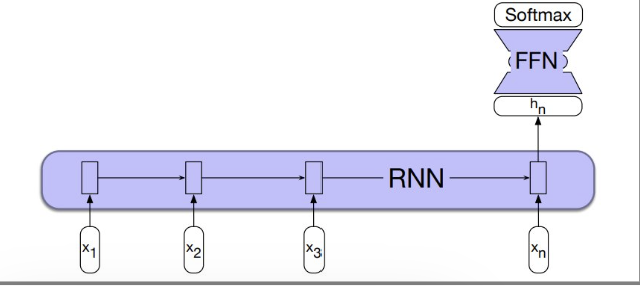


In [ ]:
# Load 64 tweets at a time
BATCH_SIZE = 64
#max length of any tweet
MAX_LEN = 50

#prepare pytorch dataset, this we convert each tweet from tokens to indices and prepare it for training
train_dataset = TweetDataset(df_train['extra_cleaned'], df_train['label'], word_to_idx, max_len=MAX_LEN)
val_dataset = TweetDataset(df_val['extra_cleaned'], df_val['label'], word_to_idx, max_len=MAX_LEN)
test_dataset = TweetDataset(df_test['extra_cleaned'], df_test['label'], word_to_idx, max_len=MAX_LEN)

#Loads 64 tweets at a time,Shuffles the tweets each epoch only in training data
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)


In [ ]:
from sklearn.metrics import f1_score, confusion_matrix
import torch.optim as optim

def train(model, loader, optimizer, criterion, device):
  #train the model
    model.train()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    #loop over each batch in the loader
    for text, labels in loader:
        text, labels = text.to(device), labels.to(device)
        #reset the gradients before calculating them
        optimizer.zero_grad()
        # pass the data to the model
        output = model(text)
        #compare the output with the labels to calculate the loss
        loss = criterion(output, labels)
        #calculate the gradients
        loss.backward()
        #upadte the weights
        optimizer.step()
        #add the loss of the current batch to the total loss
        total_loss += loss.item()
        # choose the class with highest score
        preds = output.argmax(dim=1)
        #count the number of correctly predicted labels
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    f1 = f1_score(all_labels, all_preds, average='weighted')
    return total_loss / len(loader), correct / total, f1

def evaluate(model, loader, criterion, device):
  # make the model in evaluation mode
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    #while evaluation we don't compute gradients cause we are not training
    with torch.no_grad():
        for text, labels in loader:
            text, labels = text.to(device), labels.to(device)
            output = model(text)
            loss = criterion(output, labels)
            total_loss += loss.item()
            preds = output.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    f1 = f1_score(all_labels, all_preds, average='weighted')
    cm = confusion_matrix(all_labels, all_preds)
    return total_loss / len(loader), correct / total, f1, cm, all_preds, all_labels


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# initialize the model
model = RNNModel(
    vocab_size=len(word_to_idx),
    embedding_dim=100,
    hidden_dim=128,
    output_dim=3,
    n_layers=2,
    bidirectional=True,
    dropout=0.3,
    pad_idx=word_to_idx['<PAD>']
).to(device)

optimizer = optim.Adam(model.parameters(), lr=0.001)
weights = torch.tensor([2.0, 1.0, 2.0]).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)


N_EPOCHS = 10
best_val_loss = float('inf')
# start training and evaluating the model
for epoch in range(N_EPOCHS):
    train_loss, train_acc, train_f1 = train(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc, val_f1,cm,all_preds, all_labels  = evaluate(model, val_loader, criterion, device)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_rnn_model.pt')

    print(f'Epoch {epoch+1}')
    print(f'\tTrain Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}% | Train F1: {train_f1:.3f}')
    print(f'\tVal Loss: {val_loss:.3f} | Val Acc: {val_acc*100:.2f}% | Val F1: {val_f1:.3f}')


Epoch 1
	Train Loss: 1.000 | Train Acc: 42.78% | Train F1: 0.358
	Val Loss: 0.964 | Val Acc: 52.00% | Val F1: 0.476
Epoch 2
	Train Loss: 0.951 | Train Acc: 46.66% | Train F1: 0.426
	Val Loss: 0.899 | Val Acc: 50.65% | Val F1: 0.481
Epoch 3
	Train Loss: 0.884 | Train Acc: 51.58% | Train F1: 0.489
	Val Loss: 0.887 | Val Acc: 54.85% | Val F1: 0.544
Epoch 4
	Train Loss: 0.842 | Train Acc: 54.30% | Train F1: 0.522
	Val Loss: 0.821 | Val Acc: 55.35% | Val F1: 0.533
Epoch 5
	Train Loss: 0.798 | Train Acc: 58.05% | Train F1: 0.567
	Val Loss: 0.817 | Val Acc: 60.30% | Val F1: 0.600
Epoch 6
	Train Loss: 0.769 | Train Acc: 60.06% | Train F1: 0.590
	Val Loss: 0.798 | Val Acc: 59.85% | Val F1: 0.588
Epoch 7
	Train Loss: 0.746 | Train Acc: 61.38% | Train F1: 0.604
	Val Loss: 0.838 | Val Acc: 63.15% | Val F1: 0.630
Epoch 8
	Train Loss: 0.728 | Train Acc: 63.15% | Train F1: 0.624
	Val Loss: 0.783 | Val Acc: 59.50% | Val F1: 0.576
Epoch 9
	Train Loss: 0.718 | Train Acc: 63.79% | Train F1: 0.630
	Val Lo

Test Loss: 0.971 | Test Acc: 51.82% | Test F1: 0.521


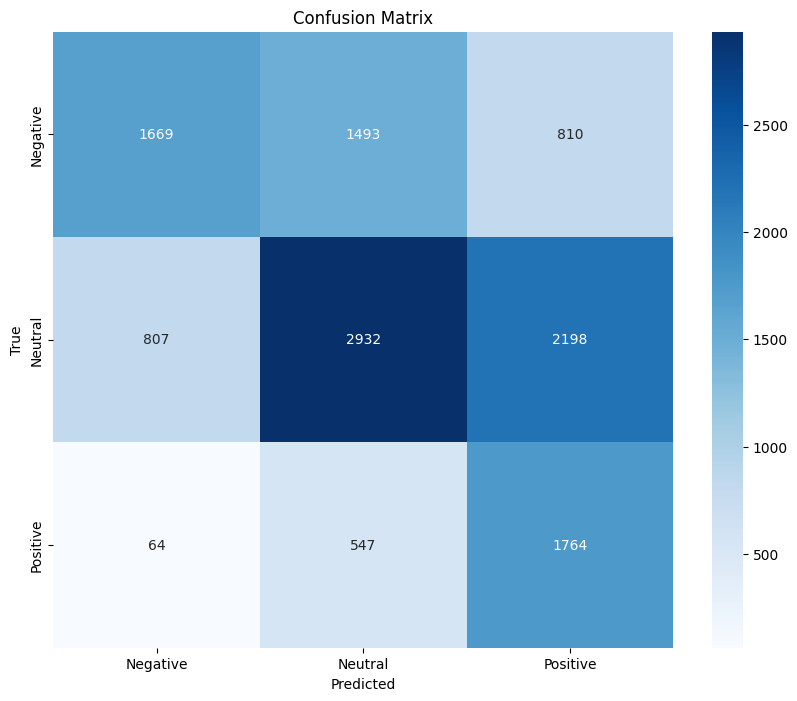

              precision    recall  f1-score   support

    Negative       0.66      0.42      0.51      3972
     Neutral       0.59      0.49      0.54      5937
    Positive       0.37      0.74      0.49      2375

    accuracy                           0.52     12284
   macro avg       0.54      0.55      0.51     12284
weighted avg       0.57      0.52      0.52     12284



In [ ]:
model.load_state_dict(torch.load('best_rnn_model.pt'))
test_loss, test_acc, test_f1, test_cm, all_preds, all_labels = evaluate(model, test_loader, criterion, device)

print(f"Test Loss: {test_loss:.3f} | Test Acc: {test_acc*100:.2f}% | Test F1: {test_f1:.3f}")

def plot_confusion_matrix(cm):
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negative', 'Neutral', 'Positive'],
                yticklabels=['Negative', 'Neutral', 'Positive'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.savefig('rnn_confusion_matrix.png')
    plt.show()

plot_confusion_matrix(test_cm)

from sklearn.metrics import classification_report

print(classification_report(all_labels, all_preds, target_names=["Negative", "Neutral", "Positive"]))


Using pre-trained embeding matrix (word2vec)


In [ ]:
!pip install gensim --upgrade


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 49.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 11.3 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.14.1
    Uninstalling scipy-1.14.1:
      Successfully uninstalled scipy-1.14.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pymc 5.21.2 requires numpy>=1.25.0, but you have numpy 1.23.0 which is incompatible.
imbalanced-learn 0.13.0 requires numpy<3,>=1.24.3, but you have numpy 1.23.0 which is incompatible.
scikit-image 0.25.2 requires numpy>=1.24, but you have numpy 1.23.0 which is incompatible.
jax 0.5.2 requires numpy>=1.25, but you have numpy 1.23.0 which is incompatible.
mizani 0.13.3 requires numpy>=1.23.5, but you have numpy 1.23.0 which is incomp

In [ ]:
import gensim.downloader as api
import numpy as np
import torch
import torch.nn as nn


In [ ]:
# Step 1: Load Word2Vec vectors
word2vec_vectors = api.load("word2vec-google-news-300")

# Step 2: Build embedding matrix
embedding_dim = 300
vocab_size = len(word_to_idx)


embedding_matrix = np.random.normal(0, 1, (vocab_size, embedding_dim))
for word, idx in word_to_idx.items():
    if word in word2vec_vectors:
        embedding_matrix[idx] = word2vec_vectors[word]




class RNNModel2(nn.Module):
  #our model takes vocab_size which is the size of the vocab i built
  #embeding dim which is the dim of the embeding vector we are going to map each word to
  #hidden dim which is the hidden memory size and this determine how much the hidden layer remember
  #output dim which is going to be 3 cause we have 3 classes
  #dropout the factor that my model is going to forget by
  #pad_idx is the index where padding started as the padding is ignored by the model
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, n_layers,
                 bidirectional, dropout, pad_idx):
        super().__init__()
        # convert each word index to dense vector and put vector of zeros to paddings
        self.embedding = nn.Embedding.from_pretrained(
    torch.tensor(embedding_matrix, dtype=torch.float32),
    padding_idx=pad_idx,
    freeze=False
)
        #input will be in this shape [batch_size, sentence_length, embedding_dim] as we made batch_first= True
        self.rnn = nn.RNN(embedding_dim, hidden_dim, num_layers=n_layers,
                          bidirectional=bidirectional, dropout=dropout if n_layers > 1 else 0,
                          batch_first=True)
        #if it is bidirectional the hidden_dim is multiplied by 2 as it reads forward and backward this
        #Takes the final hidden state and predicts the output class (positive, neutral, negative)
        self.fc = nn.Linear(hidden_dim * 2 if bidirectional else hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, text):
        embedded = self.dropout(self.embedding(text))
        output, hidden = self.rnn(embedded)
        #if it bidirectional it concatenates forward last hidden and  backward last hidden
        if self.rnn.bidirectional:
            hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        else:
          #if not it takes the last hidden state
            hidden = hidden[-1,:,:]

        return self.fc(hidden)




device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# initialize the model
model = RNNModel2(
    vocab_size=len(word_to_idx),
    embedding_dim=300,
    hidden_dim=256,
    output_dim=3,
    n_layers=3,
    bidirectional=True,
    dropout=0.3,
    pad_idx=word_to_idx['<PAD>']
).to(device)

optimizer = optim.Adam(model.parameters(), lr=0.001)
weights = torch.tensor([2.0, 1.0, 2.0]).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)


N_EPOCHS = 10
best_val_loss = float('inf')
# start training and evaluating the model
for epoch in range(N_EPOCHS):
    train_loss, train_acc, train_f1 = train(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc, val_f1,cm,all_preds, all_labels  = evaluate(model, val_loader, criterion, device)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_rnn_model.pt')

    print(f'Epoch {epoch+1}')
    print(f'\tTrain Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}% | Train F1: {train_f1:.3f}')
    print(f'\tVal Loss: {val_loss:.3f} | Val Acc: {val_acc*100:.2f}% | Val F1: {val_f1:.3f}')


[==================================================] 100.0% 1662.8/1662.8MB downloaded
Epoch 1
	Train Loss: 0.912 | Train Acc: 50.65% | Train F1: 0.484
	Val Loss: 0.835 | Val Acc: 47.85% | Val F1: 0.350
Epoch 2
	Train Loss: 0.783 | Train Acc: 60.56% | Train F1: 0.598
	Val Loss: 0.809 | Val Acc: 63.05% | Val F1: 0.621
Epoch 3
	Train Loss: 0.707 | Train Acc: 65.56% | Train F1: 0.651
	Val Loss: 0.803 | Val Acc: 64.85% | Val F1: 0.647
Epoch 4
	Train Loss: 0.655 | Train Acc: 69.06% | Train F1: 0.687
	Val Loss: 0.787 | Val Acc: 63.35% | Val F1: 0.626
Epoch 5
	Train Loss: 0.608 | Train Acc: 71.80% | Train F1: 0.715
	Val Loss: 0.844 | Val Acc: 59.70% | Val F1: 0.573
Epoch 6
	Train Loss: 0.574 | Train Acc: 73.54% | Train F1: 0.733
	Val Loss: 0.822 | Val Acc: 63.90% | Val F1: 0.638
Epoch 7
	Train Loss: 0.546 | Train Acc: 74.83% | Train F1: 0.746
	Val Loss: 0.855 | Val Acc: 62.45% | Val F1: 0.622
Epoch 8
	Train Loss: 0.518 | Train Acc: 76.60% | Train F1: 0.764
	Val Loss: 0.881 | Val Acc: 63.45% |

In [ ]:
model.load_state_dict(torch.load('best_rnn_model.pt'))
test_loss, test_acc, test_f1, test_cm, all_preds, all_labels = evaluate(model, test_loader, criterion, device)

print(f"Test Loss: {test_loss:.3f} | Test Acc: {test_acc*100:.2f}% | Test F1: {test_f1:.3f}")

def plot_confusion_matrix(cm):
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negative', 'Neutral', 'Positive'],
                yticklabels=['Negative', 'Neutral', 'Positive'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.savefig('rnn_confusion_matrix.png')
    plt.show()

plot_confusion_matrix(test_cm)

from sklearn.metrics import classification_report

print(classification_report(all_labels, all_preds, target_names=["Negative", "Neutral", "Positive"]))


# **Feedforward-based Model:**


1st trial:
Simple FeedForward NN:

> Using one hidden layer

> Using Relu activation function

> Using 100 epochs

> Using extra clean data


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from torch import nn
import torch

In [ ]:
test = df_test['extra_cleaned'].apply(lambda tokens: ' '.join(tokens))
train = df_train['extra_cleaned'].apply(lambda tokens: ' '.join(tokens))
val = df_val['extra_cleaned'].apply(lambda tokens: ' '.join(tokens))

In [ ]:
train.head()

,extra_cleaned
0,qt original draft th book remus lupin survive ...
1,ben smith smith concussion remain lineup thurs...
2,sorry bout stream last night crash tonight sur...
3,chase headley rbi double th inning david price...
4,alciato bee invest million january another sum...


In [ ]:
class FFNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim = 3):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, output_dim)  #output dim = 3 classes -> +ve , -ve & neutral

    def forward(self, x):
        x = self.relu(self.fc1(x))
        return self.fc2(x)  

Step : Vectorization with TF-IDF


In [ ]:
#Vectorization
vectorizer = TfidfVectorizer(max_features=5000)       #expects raw data not tokenized
X = vectorizer.fit_transform(train)   #size -> num_samples, 5000
y = df_train['label'].values

#convert to torch tensors
X_tensor = torch.tensor(X.toarray(), dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.long)

#instantiate the model
input_dim = X_tensor.shape[1]
hidden_dim = 128
output_dim = 3
model = FFNN(input_dim, hidden_dim, output_dim)

#define loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
input_dim

5000

Convert to tensors


In [ ]:
X_test = vectorizer.transform(test)
y_test = df_test['label'].values

X_test_tensor = torch.tensor(X_test.toarray(), dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

In [ ]:
num_epochs = 100
model.train()
for epoch in range(num_epochs):
    optimizer.zero_grad()   #clears any accumulated gradients
    outputs = model(X_tensor)         
    loss = criterion(outputs, y_tensor)
    loss.backward()
    optimizer.step()   #update the model parameters

    if (epoch+1) % 1 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")


Epoch [1/100], Loss: 1.1015
Epoch [2/100], Loss: 1.0983
Epoch [3/100], Loss: 1.0952
Epoch [4/100], Loss: 1.0921
Epoch [5/100], Loss: 1.0889
Epoch [6/100], Loss: 1.0854
Epoch [7/100], Loss: 1.0818
Epoch [8/100], Loss: 1.0780
Epoch [9/100], Loss: 1.0740
Epoch [10/100], Loss: 1.0697
Epoch [11/100], Loss: 1.0654
Epoch [12/100], Loss: 1.0608
Epoch [13/100], Loss: 1.0561
Epoch [14/100], Loss: 1.0513
Epoch [15/100], Loss: 1.0463
Epoch [16/100], Loss: 1.0412
Epoch [17/100], Loss: 1.0359
Epoch [18/100], Loss: 1.0306
Epoch [19/100], Loss: 1.0252
Epoch [20/100], Loss: 1.0196
Epoch [21/100], Loss: 1.0140
Epoch [22/100], Loss: 1.0083
Epoch [23/100], Loss: 1.0026
Epoch [24/100], Loss: 0.9967
Epoch [25/100], Loss: 0.9909
Epoch [26/100], Loss: 0.9850
Epoch [27/100], Loss: 0.9791
Epoch [28/100], Loss: 0.9732
Epoch [29/100], Loss: 0.9673
Epoch [30/100], Loss: 0.9614
Epoch [31/100], Loss: 0.9555
Epoch [32/100], Loss: 0.9496
Epoch [33/100], Loss: 0.9438
Epoch [34/100], Loss: 0.9380
Epoch [35/100], Loss: 0

In [ ]:
model.eval()
with torch.no_grad():
    outputs = model(X_test_tensor)
    predictions = torch.argmax(outputs, dim=1)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

preds = predictions.numpy()
true = y_test_tensor.numpy()

print("Accuracy:", accuracy_score(true, preds))
print("Classification Report:\n", classification_report(true, preds))

Accuracy: 0.5411917942038424
Classification Report:
               precision    recall  f1-score   support

           0       0.59      0.43      0.50      3972
           1       0.58      0.59      0.59      5937
           2       0.42      0.60      0.50      2375

    accuracy                           0.54     12284
   macro avg       0.53      0.54      0.53     12284
weighted avg       0.56      0.54      0.54     12284



2nd Trial:


In [ ]:
class FFNN2(nn.Module):
    def __init__(self, input_dim, hidden_dim_1,hidden_dim_2, output_dim = 3):
        super().__init__()
        self.layer_1 = nn.Linear(input_dim, hidden_dim_1)
        self.relu_1 = nn.ReLU()
        self.layer_2 = nn.Linear(hidden_dim_1, hidden_dim_2)  #output dim = 3 classes -> +ve , -ve & neutral
        self.relu_2 = nn.ReLU()
        self.layer_3 = nn.Linear(hidden_dim_2, output_dim)

    def forward(self, x):
        out = self.layer_1(x)
        out = self.relu_1(out)

        out = self.layer_2(out)
        out = self.relu_2(out)

        out = self.layer_3(out)

        return out

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
test = df_test['extra_cleaned'].apply(lambda tokens: ' '.join(tokens))
train = df_train['extra_cleaned'].apply(lambda tokens: ' '.join(tokens))
val = df_val['extra_cleaned'].apply(lambda tokens: ' '.join(tokens))
tfidf_vectorizer = TfidfVectorizer(max_features=2000, dtype=np.float32)
tfidfX_train = tfidf_vectorizer.fit_transform(train)
tfidfX_train = tfidfX_train.toarray()

tfidfX_val = tfidf_vectorizer.transform(val)
tfidfX_val = tfidfX_val.toarray()

tfidfX_test = tfidf_vectorizer.transform(test)
tfidfX_test = tfidfX_test.toarray()

print("TF-IDF train shape:", tfidfX_train.shape)
print("TF-IDF test shape:", tfidfX_test.shape)

print("TF-IDF val shape:", tfidfX_val.shape)

TF-IDF train shape: (45615, 2000)
TF-IDF test shape: (12284, 2000)
TF-IDF val shape: (2000, 2000)


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
vectorizer.fit(train)
print(len(vectorizer.vocabulary_))

34559


In [ ]:
import torch.optim as optim
# Dimensions of each layer and num of epochs.
input_dim = tfidfX_train.shape[1]
hidden_dim_1 = 512
hidden_dim_2 = 512

output_dim = 3
num_epochs = 150

# Define our first feed forward neural network.
first_model = FFNN2(input_dim,hidden_dim_1,hidden_dim_2,output_dim)

# Define loss function.
criterion =  nn.CrossEntropyLoss()
# criterion = nn.CrossEntropyLoss(reduction='mean')

# Define as optimizer Adam.
optimizer = optim.Adam(first_model.parameters(),lr=0.1e-3,weight_decay=1e-3)


In [ ]:
# Convert X datasets to tensors.
tfidfX_train = torch.tensor(tfidfX_train)
tfidfX_val = torch.tensor(tfidfX_val)
tfidfX_test = torch.tensor(tfidfX_test)

In [ ]:
Y_train = torch.squeeze(torch.tensor(df_train['label'].values, dtype=torch.long))
Y_val = torch.squeeze(torch.tensor(df_val['label'].values, dtype=torch.long))
Y_test = torch.squeeze(torch.tensor(df_test['label'].values, dtype=torch.long))

In [ ]:
print(Y_train.dtype)  # should be torch.float32
print(Y_train.min(), Y_train.max())

torch.int64
tensor(0) tensor(2)


In [ ]:
def calculate_accuracy(y_true, y_pred):
    # Apply softmax to get probabilities
    probabilities = F.softmax(y_pred, dim=1)
    # Get predicted class by selecting the index of maximum probability
    predicted_classes = torch.argmax(probabilities, dim=1)
    correct = (y_true == predicted_classes).float()
    acc = correct.sum() / len(correct)
    return acc

In [ ]:
# This is a function that calculate the accuracy manually
import torch.nn.functional as F
def calculate_accuracy(y_true, y_pred):
    # Apply softmax to get probabilities
    probabilities = F.softmax(y_pred, dim=1)
    # Get predicted class by selecting the index of maximum probability
    predicted_classes = torch.argmax(probabilities, dim=1)
    correct = (y_true == predicted_classes).float()
    acc = correct.sum() / len(correct)
    return acc


batch_size = 10000

# Split train dataset to mini batches
X_train_mini_batches = torch.split(tfidfX_train,batch_size)
Y_train_mini_batches = torch.split(Y_train,batch_size)

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

# Start training
for epoch in range(num_epochs):
  epoch_loss = 0
  epoch_accuracy = 0
  validation_loss=0
  val_accuracy=0

  for X_train_mini_batch,Y_train_mini_batch in zip(X_train_mini_batches,Y_train_mini_batches):


    # Forward pass to get output
    train_prediction = first_model.forward(X_train_mini_batch.float())
    #train_prediction = torch.squeeze(train_prediction)
    print(Y_train_mini_batch)
    # Calculate Loss
    train_loss = criterion(train_prediction,Y_train_mini_batch)

    # Clearing up accumulated gradients
    optimizer.zero_grad()

    # Getting gradients
    train_loss.backward()

    # Updating parameters
    optimizer.step()

    # Add each mini batch's loss
    epoch_loss += train_loss.item()

    # Add each mini batch's accuracy
    epoch_accuracy += calculate_accuracy(Y_train_mini_batch,train_prediction)

  # For some epochs print loss and accucary of train and validation set.
  if epoch % 1 == 0:

    # Forward pass to get output
    val_prediction = first_model.forward(tfidfX_val.float())
    #val_prediction = torch.squeeze(val_prediction)

    # Calculate Loss
    val_loss = criterion(val_prediction,Y_val)

    # Add each mini batch's loss
    validation_loss = val_loss.item()

    # Add each mini batch's accuracy
    val_accuracy = calculate_accuracy(Y_val,val_prediction)

    epoch_loss /= len(X_train_mini_batches)
    epoch_accuracy /= len(X_train_mini_batches)
    val_losses.append(validation_loss)
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)
    val_accuracies.append(val_accuracy)
    print("Epoch:",epoch, "\n"
           "Train_loss:",round(epoch_loss,4), "Train Accuracy:",round(epoch_accuracy.item(),4), "\n"
           "Validation_loss:  ",round(validation_loss,4), "Validation Accuracy:  ",round(val_accuracy.item(),4), "\n")


tensor([2, 1, 1,  ..., 2, 1, 1])
tensor([2, 0, 1,  ..., 1, 2, 2])
tensor([1, 1, 2,  ..., 1, 1, 1])
tensor([1, 1, 2,  ..., 1, 1, 2])
tensor([1, 2, 2,  ..., 2, 1, 1])
Epoch: 0 
Train_loss: 1.0971 Train Accuracy: 0.3935 
Validation_loss:   1.0943 Validation Accuracy:   0.44 

tensor([2, 1, 1,  ..., 2, 1, 1])
tensor([2, 0, 1,  ..., 1, 2, 2])
tensor([1, 1, 2,  ..., 1, 1, 1])
tensor([1, 1, 2,  ..., 1, 1, 2])
tensor([1, 2, 2,  ..., 2, 1, 1])
Epoch: 1 
Train_loss: 1.0926 Train Accuracy: 0.4561 
Validation_loss:   1.0902 Validation Accuracy:   0.465 

tensor([2, 1, 1,  ..., 2, 1, 1])
tensor([2, 0, 1,  ..., 1, 2, 2])
tensor([1, 1, 2,  ..., 1, 1, 1])
tensor([1, 1, 2,  ..., 1, 1, 2])
tensor([1, 2, 2,  ..., 2, 1, 1])
Epoch: 2 
Train_loss: 1.0884 Train Accuracy: 0.4656 
Validation_loss:   1.0861 Validation Accuracy:   0.434 

tensor([2, 1, 1,  ..., 2, 1, 1])
tensor([2, 0, 1,  ..., 1, 2, 2])
tensor([1, 1, 2,  ..., 1, 1, 1])
tensor([1, 1, 2,  ..., 1, 1, 2])
tensor([1, 2, 2,  ..., 2, 1, 1])
Epoch: 3 
T

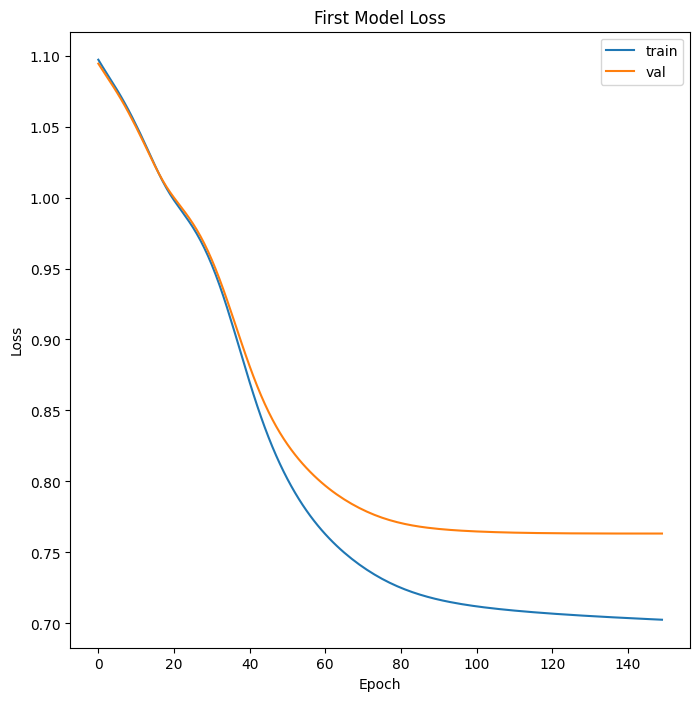

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
figure(figsize=(8,8))
plt.plot(train_losses)
plt.plot(val_losses)
plt.title('First Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'val'], loc='upper right')
plt.show()

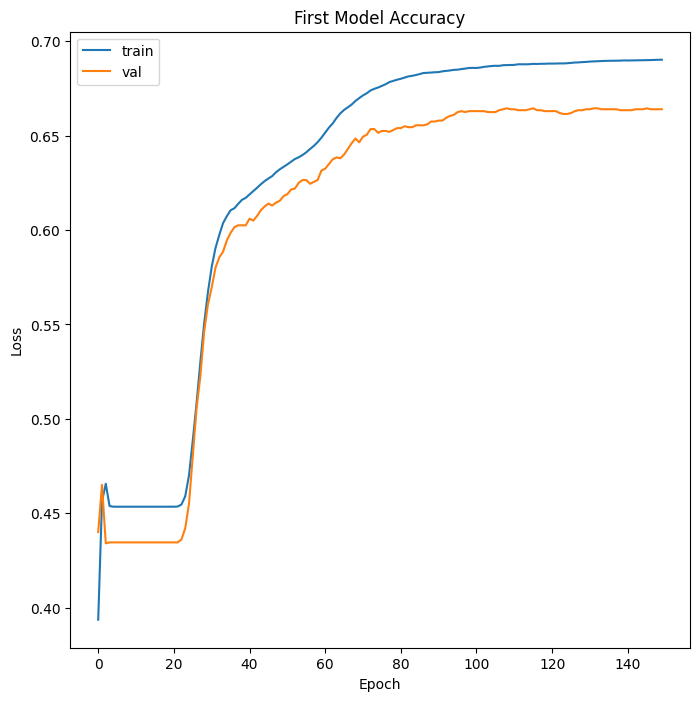

In [ ]:
figure(figsize=(8,8))
plt.plot(train_accuracies)
plt.plot(val_accuracies)
plt.title('First Model Accuracy')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [ ]:
# Forward pass to get output
test_prediction = first_model.forward(tfidfX_test.float())
test_prediction = torch.squeeze(test_prediction)

#Calculate accuracy on test set
test_accuracy = calculate_accuracy(Y_test,test_prediction)

print("Test Accuracy:",round(test_accuracy.item(),4), "\n")

Test Accuracy: 0.5824 



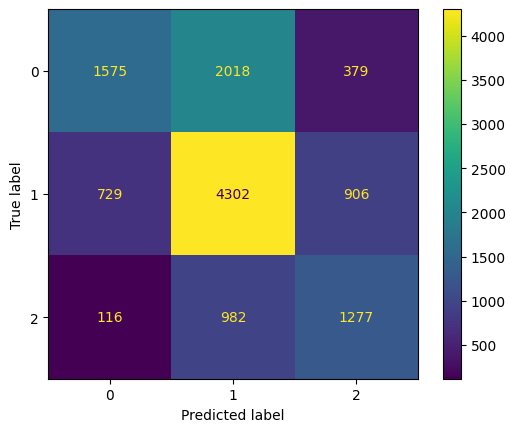

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get model predictions on test set
first_model.eval()  # set model to eval mode
with torch.no_grad():
    test_predictions = first_model(tfidfX_test.float())
    predicted_classes = torch.argmax(test_predictions, dim=1)

# Compute confusion matrix
cm = confusion_matrix(Y_test.numpy(), predicted_classes.numpy())
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1, 2])
disp.plot()
plt.show()
